# Student Performance Prediction Using Machine Learning

## 1. Introduction

Student performance can be influenced by several academic, social and personal factors such as previous grades, study time, absences, failures and family background.

This project analyzes student performance data and applies Data Science and Machine Learning techniques to understand patterns in student results and build a model that can predict whether a student is likely to pass or fail.

The project follows the complete Data Science workflow from data collection and data cleaning to exploratory data analysis, visualization, feature preparation, model building and evaluation.

## 2. Problem Statement

Educational institutions collect a large amount of student-related data, but analyzing this data manually can make it difficult to identify students who may need additional academic support.

The problem addressed in this project is to analyze student performance data and develop a Machine Learning classification model that predicts whether a student is likely to pass or fail based on selected features.

## 3. Objectives

- Understand and analyze the student performance dataset.
- Clean and prepare the data for analysis.
- Perform Exploratory Data Analysis (EDA).
- Identify important patterns and relationships in the data.
- Create meaningful visualizations.
- Prepare suitable features for Machine Learning.
- Build a classification model to predict student performance.
- Evaluate the model using appropriate performance metrics.
- Summarize the key findings and suggest future improvements.

## 4. Data Science Workflow

The following workflow is followed in this project:

Problem Definition → Data Collection → Data Understanding → Data Cleaning → EDA → Visualization → Feature Preparation → Model Building → Model Evaluation → Conclusion → Future Scope


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# Load the Student Performance dataset

data_path = "../Dataset/student-mat.csv"

df = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 395
Number of columns: 33


In [3]:
# Dataset Understanding

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Last 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9



Dataset Shape:
(395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  gua

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [4]:
# Data Cleaning

print("Missing values before cleaning:")
print(df.isnull().sum().sum())

print("\nDuplicate rows before cleaning:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

# Check unique values in important categorical columns
print("\nUnique values in selected categorical columns:")

for column in ["school", "sex", "internet", "romantic"]:
    print(f"{column}: {df[column].unique()}")

# Check for possible outliers in absences using IQR
Q1 = df["absences"].quantile(0.25)
Q3 = df["absences"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["absences"] < lower_bound) |
    (df["absences"] > upper_bound)
]

print("\nAbsences IQR:")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of possible outliers:", len(outliers))

print("\nData cleaning check completed.")

Missing values before cleaning:
0

Duplicate rows before cleaning:
0

Data types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

Unique values in selected categorical columns:
school: <StringArray>
['GP', 'MS']
Length: 2, dtype: str
sex: <StringArray>
['F', 'M']
Length: 2, dtype: str
internet: <StringArray>
['no', 'yes']
Length: 2, dtype: str
romantic: <StringArray>
['n

In [5]:
# Create cleaned dataset

clean_df = df.copy()

# Remove duplicate rows if any are present
clean_df = clean_df.drop_duplicates()

# Verify the cleaned dataset
print("Cleaned dataset shape:", clean_df.shape)
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

Cleaned dataset shape: (395, 33)
Missing values: 0
Duplicate rows: 0


In [6]:
# EDA Question 1:
# What is the average final grade (G3)?

average_g3 = clean_df["G3"].mean()

print("Average final grade (G3):", round(average_g3, 2))
print("Minimum final grade:", clean_df["G3"].min())
print("Maximum final grade:", clean_df["G3"].max())

Average final grade (G3): 10.42
Minimum final grade: 0
Maximum final grade: 20


In [7]:
# EDA Question 2:
# What is the average final grade by gender?

gender_performance = clean_df.groupby("sex")["G3"].mean()

print("Average final grade by gender:")
print(gender_performance.round(2))

Average final grade by gender:
sex
F     9.97
M    10.91
Name: G3, dtype: float64


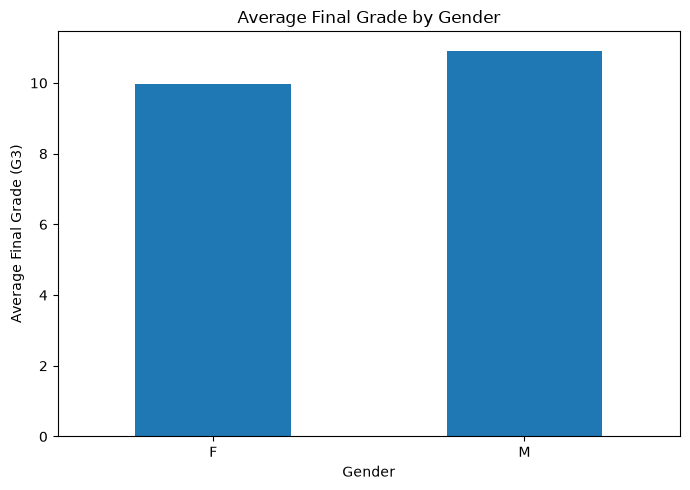

In [8]:
# Visualization 1: Average Final Grade by Gender

gender_performance.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The bar chart compares the average final grade (G3) between female and male students. In this dataset, male students have a higher average final grade than female students. However, this difference describes the sample and does not by itself establish that gender causes differences in academic performance.

In [9]:
# EDA Question 3:
# How does study time relate to average final grade?

studytime_performance = clean_df.groupby("studytime")["G3"].mean()

print("Average final grade by study time:")
print(studytime_performance.round(2))

Average final grade by study time:
studytime
1    10.05
2    10.17
3    11.40
4    11.26
Name: G3, dtype: float64


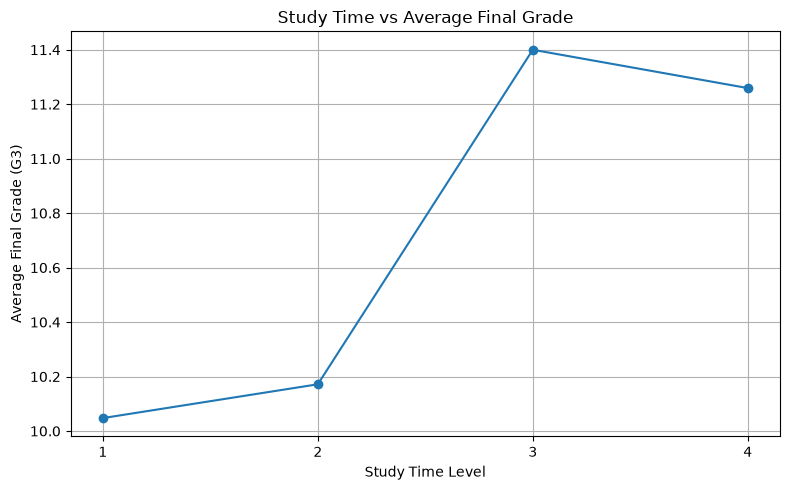

In [10]:
# Visualization 2: Study Time vs Average Final Grade

plt.figure(figsize=(8, 5))

plt.plot(
    studytime_performance.index,
    studytime_performance.values,
    marker="o"
)

plt.title("Study Time vs Average Final Grade")
plt.xlabel("Study Time Level")
plt.ylabel("Average Final Grade (G3)")
plt.xticks([1, 2, 3, 4])
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The line chart shows the average final grade for each study-time level. The relationship is not perfectly linear, meaning that increasing study time does not always correspond to a steadily increasing average grade. Study time is therefore one factor among several that may be associated with student performance.

In [11]:
# EDA Question 4:
# How do previous failures relate to average final grade?

failure_performance = clean_df.groupby("failures")["G3"].mean()

print("Average final grade by number of previous failures:")
print(failure_performance.round(2))

Average final grade by number of previous failures:
failures
0    11.25
1     8.12
2     6.24
3     5.69
Name: G3, dtype: float64


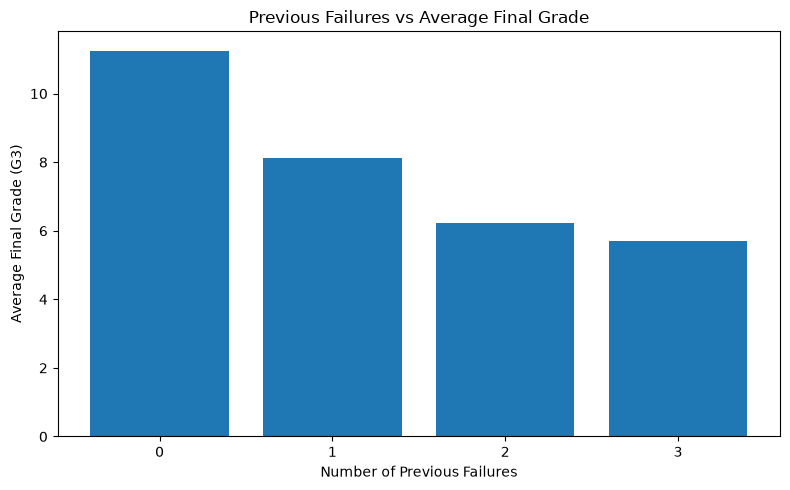

In [12]:
# Visualization 3: Previous Failures vs Average Final Grade

plt.figure(figsize=(8, 5))

plt.bar(
    failure_performance.index.astype(str),
    failure_performance.values
)

plt.title("Previous Failures vs Average Final Grade")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average Final Grade (G3)")
plt.tight_layout()
plt.show()

### Interpretation

The chart shows a clear difference in average final grades across students with different numbers of previous failures. Students with no previous failures have the highest average final grade in this dataset, while students with more previous failures have lower average grades. This indicates an association between previous failures and final performance, although it does not prove that failures alone cause lower grades.

In [13]:
# EDA Question 5:
# Does internet access relate to average final grade?

internet_performance = clean_df.groupby("internet")["G3"].mean()

print("Average final grade by internet access:")
print(internet_performance.round(2))

Average final grade by internet access:
internet
no      9.41
yes    10.62
Name: G3, dtype: float64


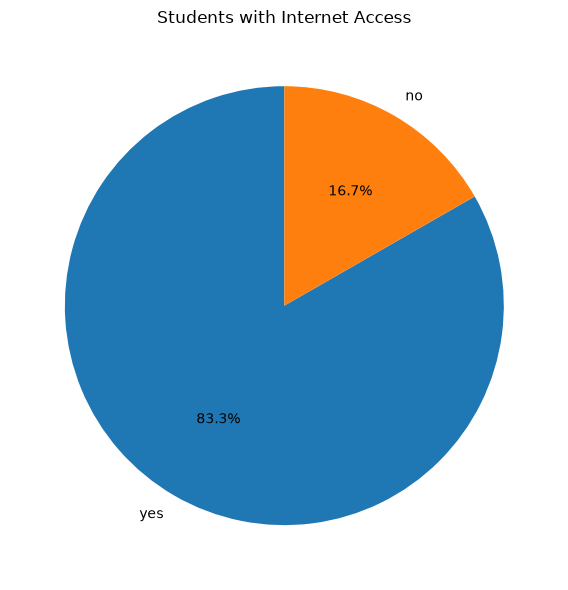

In [14]:
# Visualization 4: Internet Access Distribution

internet_counts = clean_df["internet"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    internet_counts.values,
    labels=internet_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Students with Internet Access")
plt.tight_layout()
plt.show()

### Interpretation

The pie chart shows the proportion of students with and without internet access at home. Most students in the dataset have internet access. The average final grade is also higher for students with internet access, although this is an association and other factors may also influence academic performance.

In [15]:
# EDA Question 6:
# How does mother's education relate to average student performance?

mother_education_performance = clean_df.groupby("Medu")["G3"].mean()

print("Average final grade by mother's education level:")
print(mother_education_performance.round(2))

Average final grade by mother's education level:
Medu
0    13.00
1     8.68
2     9.73
3    10.30
4    11.76
Name: G3, dtype: float64


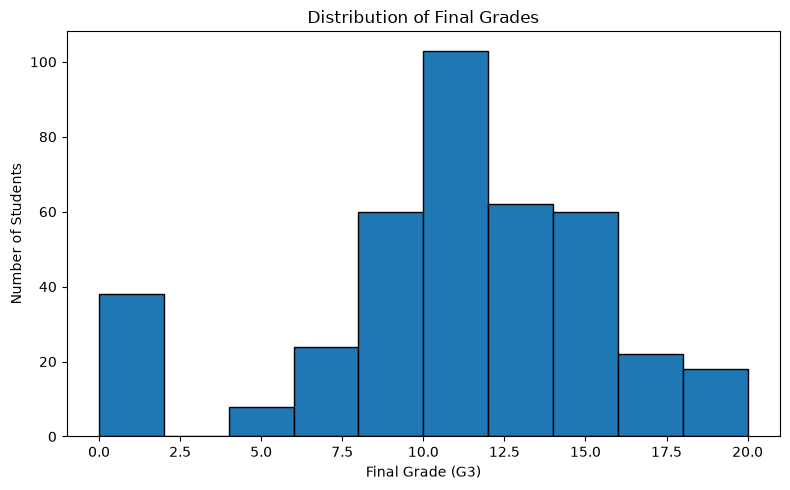

In [16]:
# Visualization 5: Distribution of Final Grades

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["G3"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

### Interpretation

The histogram shows how the final grades (G3) are distributed among students. The grades cover a wide range from 0 to 20, with many students concentrated around the middle of the distribution. This helps identify the general pattern of student performance and the spread of grades.

In [17]:
# EDA Question 7:
# Is there a relationship between absences and final grade?

absence_correlation = clean_df["absences"].corr(clean_df["G3"])

print("Correlation between absences and final grade:", round(absence_correlation, 2))

Correlation between absences and final grade: 0.03


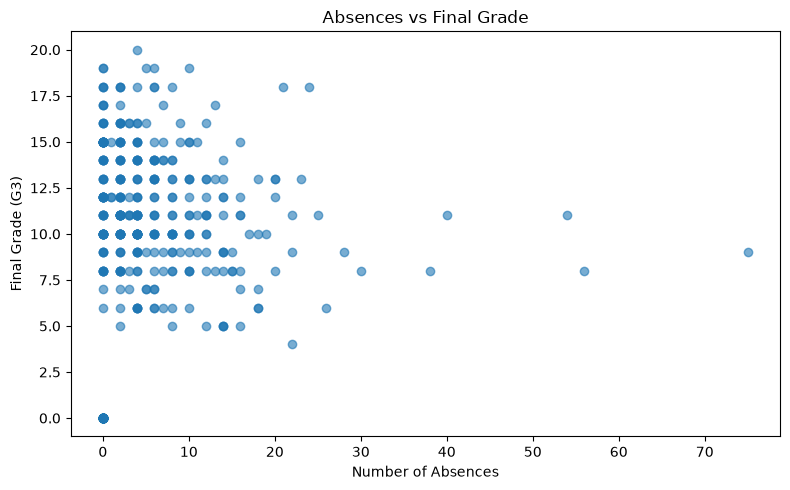

In [18]:
# Visualization 6: Absences vs Final Grade

plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["absences"],
    clean_df["G3"],
    alpha=0.6
)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot compares student absences with final grades. The correlation is approximately 0.03, indicating a very weak linear relationship between the two variables in this dataset. Therefore, absences alone do not appear to strongly explain variation in final grades.

In [19]:
# EDA Question 8:
# How are G1, G2 and G3 related?

grade_correlation = clean_df[["G1", "G2", "G3"]].corr()

print("Correlation between G1, G2 and G3:")
display(grade_correlation.round(2))

Correlation between G1, G2 and G3:


,G1,G2,G3
G1,1.00,0.85,0.8
G2,0.85,1.00,0.9
G3,0.80,0.90,1.0


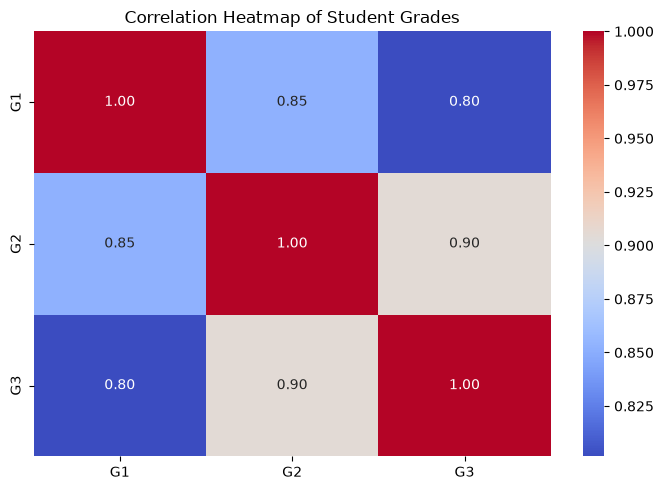

In [20]:
# Visualization 7: Correlation Heatmap

plt.figure(figsize=(7, 5))

sns.heatmap(
    grade_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Student Grades")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap shows strong positive correlations between G1, G2 and G3. G2 has the strongest correlation with G3 at approximately 0.90, while G1 has a correlation of approximately 0.80 with G3. This indicates that previous-period grades are strongly associated with the final grade in this dataset.

In [21]:
# EDA Question 9:
# How does school type relate to average final grade?

school_performance = clean_df.groupby("school")["G3"].mean()

print("Average final grade by school:")
print(school_performance.round(2))

Average final grade by school:
school
GP    10.49
MS     9.85
Name: G3, dtype: float64


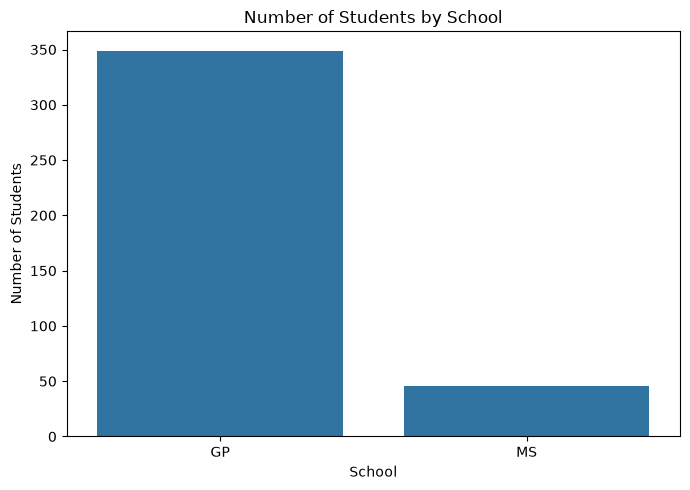

In [22]:
# Visualization 8: Number of Students by School

plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="school"
)

plt.title("Number of Students by School")
plt.xlabel("School")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

In [23]:
### Interpretation

The count plot shows the number of students from each school in the dataset. The dataset contains more students from GP school than MS school. The average final grade is also slightly higher for GP students, although the difference should be interpreted as a pattern in this sample rather than a causal effect of school type.

SyntaxError: invalid syntax (1639347808.py, line 3)

### Interpretation

The count plot shows the number of students from each school in the dataset. The dataset contains more students from GP school than MS school. The average final grade is also slightly higher for GP students, although the difference should be interpreted as a pattern in this sample rather than a causal effect of school type.

In [24]:
# EDA Question 10:
# How are final grades distributed across different age groups?

age_performance = clean_df.groupby("age")["G3"].mean()

print("Average final grade by age:")
print(age_performance.round(2))

Average final grade by age:
age
15    11.26
16    11.03
17    10.28
18     9.55
19     8.21
20    14.00
21     7.00
22     8.00
Name: G3, dtype: float64


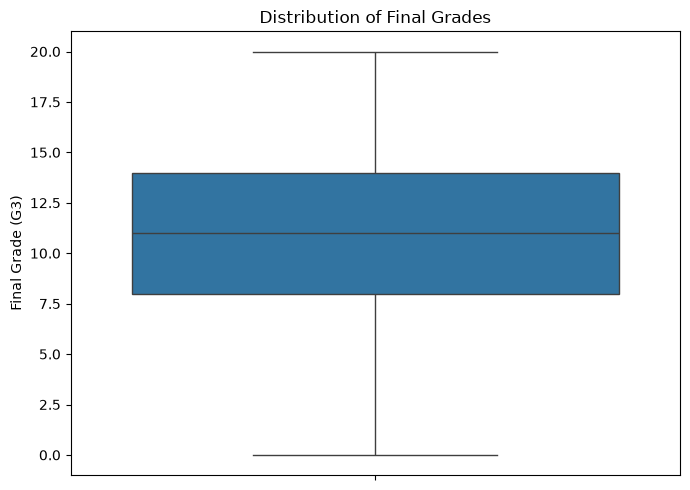

In [25]:
# Visualization 9: Distribution of Final Grades

plt.figure(figsize=(7, 5))

sns.boxplot(
    y=clean_df["G3"]
)

plt.title("Distribution of Final Grades")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

### Interpretation

The box plot summarizes the distribution of final grades. The median final grade is around 11, while the middle 50% of students are concentrated between approximately 8 and 14. The plot also helps identify unusually low or high grade values in the dataset.

In [26]:
# Feature Preparation
# Create a binary target variable: Pass = 1, Fail = 0

clean_df["pass"] = (clean_df["G3"] >= 10).astype(int)

print("Target variable created successfully.")
print("\nPass/Fail counts:")
print(clean_df["pass"].value_counts())

print("\nPass/Fail percentages:")
print((clean_df["pass"].value_counts(normalize=True) * 100).round(2))

Target variable created successfully.

Pass/Fail counts:
pass
1    265
0    130
Name: count, dtype: int64

Pass/Fail percentages:
pass
1    67.09
0    32.91
Name: proportion, dtype: float64


In [27]:
# Select features for Machine Learning

features = [
    "age",
    "Medu",
    "Fedu",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2"
]

X = clean_df[features]
y = clean_df["pass"]

print("Features selected:", features)
print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Features selected: ['age', 'Medu', 'Fedu', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Feature matrix shape: (395, 14)
Target shape: (395,)


In [28]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training target samples:", y_train.shape[0])
print("Testing target samples:", y_test.shape[0])

Training samples: 316
Testing samples: 79
Training target samples: 316
Testing target samples: 79


In [29]:
# Build the Logistic Regression model

model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [30]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.
First 10 predictions:
[1 0 1 1 1 1 1 0 1 1]


In [31]:
# Evaluate the Machine Learning model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Model Evaluation Results
------------------------
Accuracy : 0.8987
Precision: 0.9787
Recall   : 0.8679
F1-Score : 0.92


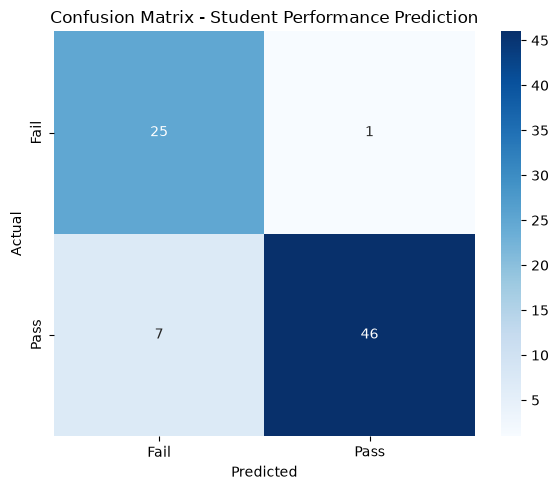

In [32]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Confusion Matrix - Student Performance Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [33]:
# Detailed Classification Report

print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fail", "Pass"]
    )
)

Classification Report
---------------------
              precision    recall  f1-score   support

        Fail       0.78      0.96      0.86        26
        Pass       0.98      0.87      0.92        53

    accuracy                           0.90        79
   macro avg       0.88      0.91      0.89        79
weighted avg       0.91      0.90      0.90        79



<Figure size 700x500 with 0 Axes>

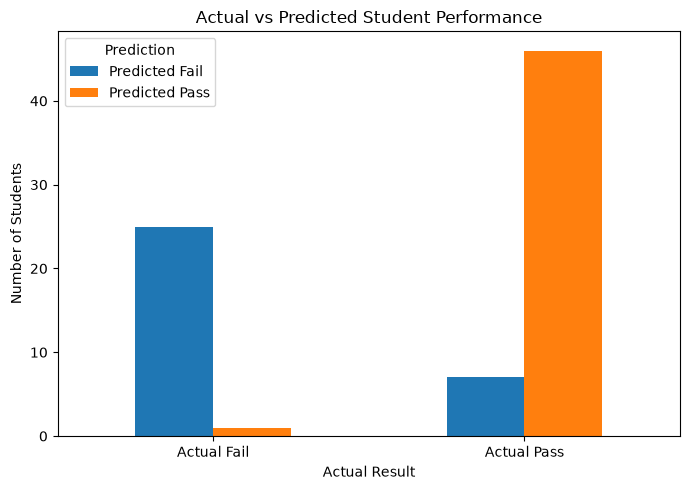

In [34]:
# Visualization: Actual vs Predicted Pass/Fail

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison_counts = pd.crosstab(
    comparison["Actual"],
    comparison["Predicted"]
)

comparison_counts.index = ["Actual Fail", "Actual Pass"]
comparison_counts.columns = ["Predicted Fail", "Predicted Pass"]

plt.figure(figsize=(7, 5))

comparison_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Actual vs Predicted Student Performance")
plt.xlabel("Actual Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Prediction")
plt.tight_layout()
plt.show()

### Interpretation

The chart compares the actual student outcomes with the outcomes predicted by the Logistic Regression model. The model correctly identifies most of the students in both categories, although some predictions differ from the actual outcomes. The evaluation metrics provide a numerical summary of this performance.

In [35]:
# Final Model Performance Summary

model_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

model_results["Percentage"] = (
    model_results["Score"] * 100
).round(2)

display(model_results)

,Metric,Score,Percentage
0,Accuracy,0.898734,89.87
1,Precision,0.978723,97.87
2,Recall,0.867925,86.79
3,F1-Score,0.920000,92.00


# Key Findings

1. The dataset contains 395 student records and 33 variables.

2. The average final grade (G3) is approximately 10.42 out of 20.

3. The dataset contains 265 students classified as Pass and 130 students classified as Fail using the selected passing threshold of G3 >= 10.

4. Students with no previous failures have a higher average final grade than students with previous failures.

5. G1 and G2 have strong positive relationships with G3. In particular, G2 has a correlation of approximately 0.90 with G3.

6. The correlation between absences and final grade is approximately 0.03, indicating a very weak linear relationship in this dataset.

7. The dataset contains more students from GP school than MS school.

8. Students with internet access have a higher average final grade in this sample, although this is an association and not proof of causation.

9. The Logistic Regression classification model achieved approximately 89.87% accuracy on the test dataset.

10. The model achieved approximately 97.87% precision, 86.79% recall and 90.00% F1-score.

# Conclusion

This project applied the complete Data Science workflow to a Student Performance dataset. The data was loaded, understood, cleaned and explored using Python libraries such as Pandas, NumPy, Matplotlib and Seaborn.

Exploratory Data Analysis helped identify relationships between student characteristics, previous grades and final performance. Previous failures showed an association with lower final grades, while G1 and G2 showed strong positive relationships with G3.

A Logistic Regression model was then developed to classify students into Pass and Fail categories. The model achieved 89.87% accuracy, with a precision of 97.87%, recall of 86.79% and F1-score of 90.00% on the test dataset.

The results demonstrate how Data Science and Machine Learning can be used to analyze student performance and develop a basic predictive model. However, the model should not be treated as a definitive judgment about individual students because the dataset is limited and predictions depend on the available features.

# Future Scope

- Use a larger and more diverse student dataset.
- Include additional academic and behavioral features.
- Compare Logistic Regression with other classification algorithms such as Decision Tree, Random Forest and Support Vector Machine.
- Perform hyperparameter tuning to improve model performance.
- Use cross-validation for more reliable model evaluation.
- Develop a simple web application where educators can enter student information and obtain a prediction.
- Continuously evaluate the model on new data before using it in a real educational setting.

# Machine Learning Fundamentals

## 1. What is Machine Learning?

Machine Learning (ML) is a branch of Artificial Intelligence that allows computers to learn patterns from data and make predictions or decisions without being explicitly programmed for every situation.

Machine Learning is an important part of Data Science. Data Science involves collecting, cleaning, analyzing and visualizing data, while Machine Learning can be used to build predictive models from that data.

In this project, Machine Learning is used to predict whether a student is likely to Pass or Fail.

---

## 2. Types of Machine Learning

### Supervised Learning

Supervised Learning uses labeled data, where the input data and the correct output are already known.

**Example:** Predicting whether a student will Pass or Fail using previous student information.

### Unsupervised Learning

Unsupervised Learning works with data that does not have predefined output labels. It attempts to discover patterns or groups in the data.

**Example:** Grouping customers into different customer segments based on their purchasing behavior.

### Reinforcement Learning

Reinforcement Learning is a learning method where an agent learns by interacting with an environment and receiving rewards or penalties.

**Example:** A robot learning how to navigate an environment by receiving rewards for reaching the correct destination.

---

## 3. Regression

Regression is a supervised Machine Learning technique used to predict a continuous numerical value.

### Linear Regression

Linear Regression models the relationship between one or more independent variables and a continuous dependent variable.

**Independent variable:** The input feature used for prediction.

**Dependent variable:** The output value that we want to predict.

**Example:** Predicting house price using area, number of bedrooms and location-related features.

In this project, the target is Pass/Fail, so the project uses Classification rather than Regression.

---

## 4. Classification

Classification is a supervised Machine Learning technique used to predict categories or classes.

### Binary Classification

Binary classification has two possible classes.

**Example:** Pass / Fail

This project uses binary classification:

- 0 = Fail
- 1 = Pass

### Multi-Class Classification

Multi-class classification has more than two possible classes.

**Example:** Classifying an image as a cat, dog, bird or horse.

---

## 5. Machine Learning Evaluation Metrics

### Accuracy

Accuracy is the proportion of all predictions that are correct.

**Useful when:** The classes are reasonably balanced and overall correctness is important.

### Precision

Precision measures how many of the observations predicted as a particular positive class are actually positive.

**Useful when:** False positive predictions are important to control.

### Recall

Recall measures how many of the actual positive observations were correctly identified.

**Useful when:** Missing a positive case is more important to avoid.

### F1-Score

F1-score combines Precision and Recall into a single metric.

**Useful when:** Both precision and recall are important.

### MAE

Mean Absolute Error measures the average absolute difference between actual and predicted numerical values.

**Useful for:** Regression problems.

### MSE

Mean Squared Error calculates the average squared difference between actual and predicted numerical values.

**Useful for:** Regression problems where larger errors should receive more penalty.

### RMSE

Root Mean Squared Error is the square root of MSE.

**Useful for:** Regression problems because the result is expressed in the same units as the target variable.

### R²

R², or coefficient of determination, measures how much of the variation in a continuous target variable is explained by a regression model.

**Useful for:** Regression problems.

---

## Metrics Used in This Project

Since this project is a binary classification problem, the main evaluation metrics used are:

- Accuracy
- Precision
- Recall
- F1-Score

The final Logistic Regression results were:

- Accuracy: 89.87%
- Precision: 97.87%
- Recall: 86.79%
- F1-Score: 90.00%

MAE, MSE, RMSE and R² were not used because they are primarily regression evaluation metrics, while this project predicts Pass/Fail classes.

# Machine Learning Fundamentals

## 1. What is Machine Learning?

Machine Learning (ML) is a branch of Artificial Intelligence that allows computers to learn patterns from data and make predictions or decisions without being explicitly programmed for every situation.

Machine Learning is an important part of Data Science. Data Science involves collecting, cleaning, analyzing and visualizing data, while Machine Learning can be used to build predictive models from that data.

In this project, Machine Learning is used to predict whether a student is likely to Pass or Fail.

---

## 2. Types of Machine Learning

### Supervised Learning

Supervised Learning uses labeled data, where the input data and the correct output are already known.

**Example:** Predicting whether a student will Pass or Fail using previous student information.

### Unsupervised Learning

Unsupervised Learning works with data that does not have predefined output labels. It attempts to discover patterns or groups in the data.

**Example:** Grouping customers into different customer segments based on their purchasing behavior.

### Reinforcement Learning

Reinforcement Learning is a learning method where an agent learns by interacting with an environment and receiving rewards or penalties.

**Example:** A robot learning how to navigate an environment by receiving rewards for reaching the correct destination.

---

## 3. Regression

Regression is a supervised Machine Learning technique used to predict a continuous numerical value.

### Linear Regression

Linear Regression models the relationship between one or more independent variables and a continuous dependent variable.

**Independent variable:** The input feature used for prediction.

**Dependent variable:** The output value that we want to predict.

**Example:** Predicting house price using area, number of bedrooms and location-related features.

In this project, the target is Pass/Fail, so the project uses Classification rather than Regression.

---

## 4. Classification

Classification is a supervised Machine Learning technique used to predict categories or classes.

### Binary Classification

Binary classification has two possible classes.

**Example:** Pass / Fail

This project uses binary classification:

- 0 = Fail
- 1 = Pass

### Multi-Class Classification

Multi-class classification has more than two possible classes.

**Example:** Classifying an image as a cat, dog, bird or horse.

---

## 5. Machine Learning Evaluation Metrics

### Accuracy

Accuracy is the proportion of all predictions that are correct.

**Useful when:** The classes are reasonably balanced and overall correctness is important.

### Precision

Precision measures how many of the observations predicted as a particular positive class are actually positive.

**Useful when:** False positive predictions are important to control.

### Recall

Recall measures how many of the actual positive observations were correctly identified.

**Useful when:** Missing a positive case is more important to avoid.

### F1-Score

F1-score combines Precision and Recall into a single metric.

**Useful when:** Both precision and recall are important.

### MAE

Mean Absolute Error measures the average absolute difference between actual and predicted numerical values.

**Useful for:** Regression problems.

### MSE

Mean Squared Error calculates the average squared difference between actual and predicted numerical values.

**Useful for:** Regression problems where larger errors should receive more penalty.

### RMSE

Root Mean Squared Error is the square root of MSE.

**Useful for:** Regression problems because the result is expressed in the same units as the target variable.

### R²

R², or coefficient of determination, measures how much of the variation in a continuous target variable is explained by a regression model.

**Useful for:** Regression problems.

---

## Metrics Used in This Project

Since this project is a binary classification problem, the main evaluation metrics used are:

- Accuracy
- Precision
- Recall
- F1-Score

The final Logistic Regression results were:

- Accuracy: 89.87%
- Precision: 97.87%
- Recall: 86.79%
- F1-Score: 90.00%

MAE, MSE, RMSE and R² were not used because they are primarily regression evaluation metrics, while this project predicts Pass/Fail classes.

# Tools & Technologies

- **Python** – Programming language used for data analysis and Machine Learning.
- **Jupyter Notebook** – Development environment used to create and document the project.
- **Pandas** – Used for data loading, manipulation and analysis.
- **NumPy** – Used for numerical operations.
- **Matplotlib** – Used for data visualization.
- **Seaborn** – Used for statistical visualizations.
- **Scikit-learn** – Used for data splitting, model building and evaluation.
- **Git** – Used for version control.
- **GitHub** – Used to store and manage the project repository.

# Dataset Description

The project uses the Student Performance dataset containing information about students and their academic, social and personal characteristics.

The dataset contains:

- **395 records**
- **33 columns**

Important variables include:

- `age` – Student age
- `sex` – Student gender
- `Medu` – Mother's education level
- `Fedu` – Father's education level
- `studytime` – Weekly study time category
- `failures` – Number of previous failures
- `internet` – Internet access at home
- `absences` – Number of school absences
- `G1` – First-period grade
- `G2` – Second-period grade
- `G3` – Final grade

For Machine Learning, `G3` was converted into a binary target:

- **Pass = 1:** G3 >= 10
- **Fail = 0:** G3 < 10

# Final Project Summary

## Project Title
**Student Performance Prediction Using Machine Learning**

## Introduction
This project analyzes student performance data using Data Science and Machine Learning techniques. The aim is to identify patterns in student academic performance and develop a Machine Learning model to predict whether a student is likely to pass or fail.

## Problem Statement
Educational institutions can use student data to identify performance patterns and provide appropriate academic support. This project develops a basic classification model to predict student Pass/Fail status based on selected student-related and academic features.

## Objectives
- Analyze student performance data.
- Clean and prepare the dataset.
- Perform Exploratory Data Analysis.
- Create meaningful visualizations.
- Identify important patterns in student performance.
- Prepare features for Machine Learning.
- Build a classification model.
- Evaluate the model using classification metrics.
- Identify limitations and future improvements.

## Dataset
The dataset contains 395 student records and 33 variables related to academic performance, demographics, family background and student activities.

## Data Cleaning
The dataset contained no missing values and no duplicate records. Data types were checked and found to be appropriate. Fifteen possible outliers were identified in the absences column using the IQR method. These observations were retained because high absence values can represent genuine student records.

## Exploratory Data Analysis
Ten meaningful questions were investigated using statistical analysis and visualizations. Important relationships were observed between previous failures, previous grades, internet access, study time, absences and final performance.

## Machine Learning
A Logistic Regression model was used for binary classification. Students were classified as Pass when G3 was greater than or equal to 10 and Fail when G3 was below 10.

The data was divided into 80% training data and 20% testing data.

## Model Evaluation

| Metric | Result |
|---|---:|
| Accuracy | 89.87% |
| Precision | 97.87% |
| Recall | 86.79% |
| F1-Score | 90.00% |

## Key Findings
- The average final grade was 10.42.
- Students with previous failures had lower average final grades in the dataset.
- G2 showed a strong positive relationship with G3.
- Absences had a very weak linear correlation with G3.
- Students with internet access had a higher average G3 in this sample.
- The Logistic Regression model achieved 89.87% accuracy on the test data.

## Conclusion
The project demonstrates how the complete Data Science workflow can be applied to student performance data. Data cleaning, EDA and visualization helped identify important patterns, while Machine Learning provided a basic approach for predicting Pass/Fail outcomes.

The model performed well on the selected test data, but the results should be interpreted carefully because the dataset is limited and model predictions depend on the selected features.

## Future Scope
Future work can include larger datasets, additional features, comparison of multiple Machine Learning algorithms, hyperparameter tuning, cross-validation and development of a web-based prediction application.

## GitHub Repository

**Repository:**  
https://github.com/sagardas27/data-science-python-assignment